### Why we need the evaluation 
Evaluating a model is the most critical step in the development process to ensure its **alignment with reality.** Contrary to intuition, achieving 100% efficiency is not ideal, as it often indicates that the model has become **biased toward the training data—a** phenomenon known as **Overfitting**. Evaluation methods vary depending on the data's nature and the model's architecture; a metric that is highly effective for one dataset might fail significantly with another. Therefore, it is essential to analyze the characteristics of each metric to ensure it is applied in **the appropriate context**.

In [33]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt

In [34]:
import sys
sys.path.append("..")
from utils import gradientDescent,split_data


### Mean Absolute Error (MAE)
Mean Absolute Error (MAE) : is a straightforward metric that calculates the average of the **absolute** differences between **predicted** and **actual values**. One of its primary advantages is that the result is expressed in **the same units as the original data**, making it intuitively easy for humans to understand as a **'margin of error.'** For example, if a house is predicted to cost 100k but its actual price is 110k, we can simply say the error is 10k . Perhaps its most significant feature regarding data nature is its high resistance to **outliers**, as it treats all errors linearly without any amplification (unlike squared error metrics).
$$ MAE= \frac{1}{m} \sum_{i=1}^{m}(|y-\widehat{y}|)$$

In [35]:
MAE = lambda y, y_pred: np.mean(np.abs(y - y_pred))

### Mean Squared Error (MSE)
Mean Squared Error (MSE) follows a logic similar to MAE but **squares the differences before averaging**. This mathematical choice makes the metric **highly sensitive to outliers**, acting as an analytical lens that defines the model's behavior: it shows high tolerance for small errors (as squaring a fraction makes it smaller) but is extremely **aggressive** toward large errors. This '**quadratic penalty**' forces the model to prioritize reducing significant deviations over minor ones. However, a major drawback is that squaring the results causes them to lose their direct connection to the original data units, making it **less intuitive** for human interpretation.
$$ MSE= \frac{1}{m} \sum_{i=1}^{m}(y-\widehat{y})^{2}$$

In [36]:
MSE = lambda y, y_pred: np.mean((y - y_pred) ** 2)

In [37]:
#generate random data to test MSE , MAE
np.random.seed(1)
simple_size = 1000
X = np.random.random(simple_size)*10

#the true weights
W = np.array([0.4,4])
X_with_bias = np.c_[X,np.ones(shape=(simple_size,1))] # we add the bias term to the input data

noise = np.random.random(simple_size) # we add some noise to the data

y = np.dot(X_with_bias,W) + noise



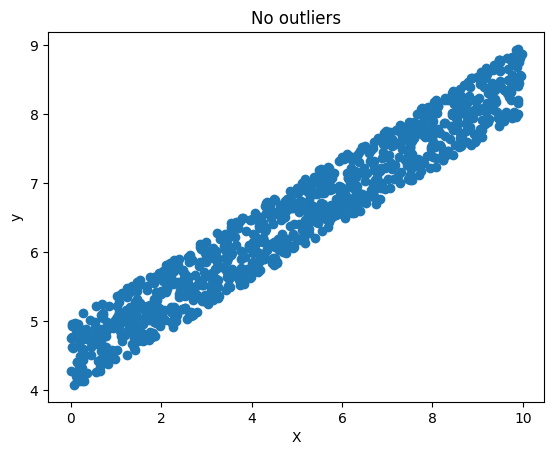

In [38]:
def plot_scater(X,y,title,xlabel,ylabel):
    plt.scatter(X,y)
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title("No outliers")
    plt.show()

plot_scater(X, y, title="No outliers", xlabel="X", ylabel="y")


In [39]:
#spliting data into train and test sets
test_size = 0.2
X_train_no_outliers, y_train_no_outliers, X_test_no_outliers, y_test_no_outliers = split_data(X_with_bias,y,test_size=test_size)
w_trained_no_outliers= gradientDescent(X_train_no_outliers,y_train_no_outliers ,learning_rate=0.01,epochs=1000)[0]
print("Trained weights : ",w_trained_no_outliers)
y_pred_no_outliers = np.dot(X_test_no_outliers,w_trained_no_outliers)
MSE_no_outliers = MSE(y_test_no_outliers,y_pred_no_outliers)
MAE_no_outliers = MAE(y_test_no_outliers,y_pred_no_outliers)
print("no outliers - MSE : ",MSE_no_outliers)    
print("no outliers - MAE : ",MAE_no_outliers)



Trained weights :  [0.4603611  4.12227597]
no outliers - MSE :  0.12690799954874651
no outliers - MAE :  0.30075800957318927


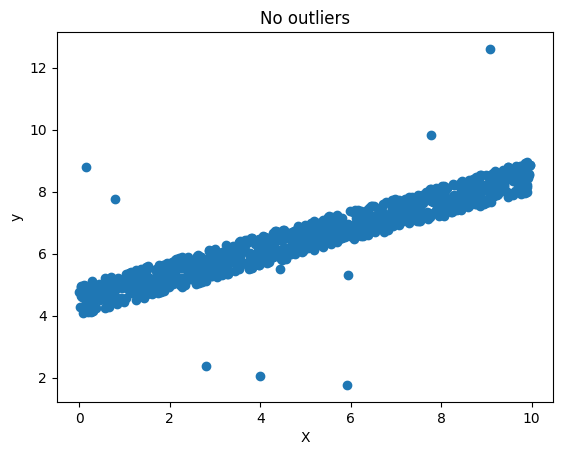

In [40]:
rng =np.random.default_rng(seed=1)
outliers = np.random.choice(simple_size, size=10, replace=False)
y_with_outliers = y.copy()
y_with_outliers[outliers] += rng.integers(low=-5, high=5, size=10) # adding outliers to the data
plot_scater(X, y_with_outliers, title="With outliers", xlabel="X", ylabel="y")

In [41]:
X_train_with_outliers, y_train_with_outliers, X_test_with_outliers, y_test_with_outliers = split_data(X_with_bias,y_with_outliers,test_size=test_size)

w_trained_with_outliers= gradientDescent(X_train_with_outliers,y_train_with_outliers ,learning_rate=0.01,epochs=1000)[0]
print("Trained weights : ",w_trained_with_outliers)
y_pred_with_outliers = np.dot(X_test_with_outliers,w_trained_with_outliers)
MSE_with_outliers = MSE(y_test_with_outliers,y_pred_with_outliers)
MAE_with_outliers = MAE(y_test_with_outliers,y_pred_with_outliers)
print("with outliers - MSE : ",MSE_with_outliers)
print("with outliers - MAE : ",MAE_with_outliers)

Trained weights :  [0.46041016 4.11565722]
with outliers - MSE :  0.2779077992582394
with outliers - MAE :  0.34331309801460813


**Empirical Observation:**  

The results clearly demonstrate the difference in sensitivity between MSE and MAE. When outliers were introduced, **MSE increased by approximately 24%**, highlighting its aggressive penalty for large deviations. Conversely, **MAE only increased by about 3.8%**, proving its robustness and stability in the presence of noise. This confirms that while MSE is useful for training models to avoid large errors, MAE provides a more stable reflection of the average error magnitude.

---

### Root Mean Squared Error (RMSE) - The Risk Reality Check
**RMSE** serves as the practical interpretation of the **'Risk Factor'** established by MSE. If MSE represents the abstract level of **risk** or the **lack of confidence** in a model's reliability (where a higher value equals lower confidence), RMSE provides the **actual magnitude** of that risk. It translates the penalty of miscalculation back into a tangible figure. Essentially, it warns the user: 'This model might provide **misleading** results with a potential error margin of (X units).' This makes it the final gatekeeper for deciding whether the model's 'risk' is acceptable in a real-world application.
$$ RMSE= \sqrt{  \frac{1}{m}  \sum_{i=1}^{m}(y-\widehat{y})^{2}}$$



In [42]:
RMSE = lambda y, y_pred: np.sqrt(MSE(y, y_pred))

In [43]:
RMSE_no_outliers = RMSE(y_test_no_outliers,y_pred_no_outliers)
RMSE_with_outliers = RMSE(y_test_with_outliers,y_pred_with_outliers)
print(f"no outliers - RMSE : {RMSE_no_outliers} , MAE : {MAE_no_outliers}")
print(f"with outliers - RMSE : {RMSE_with_outliers} , MAE : {MAE_with_outliers}")

no outliers - RMSE : 0.3562414904931015 , MAE : 0.30075800957318927
with outliers - RMSE : 0.5271696114707669 , MAE : 0.34331309801460813


**Empirical Analysis of Outlier Influence**  
The results provide a clear diagnostic: In the clean dataset,**MAE (0.29)** and **RMSE (0.34)** are relatively close, indicating a stable model. However, in the dataset with outliers, while **MAE (0.3)** remained almost unchanged—effectively ignoring the **anomalies—RMSE jumped to 0.38**. This gap serves as a clear warning signal: the model has been biased by outliers, creating a higher risk of misleading predictions. This confirms that RMSE acts as a 'risk-detector' for errors that fly under the radar of MAE.

---


**Root Mean Squared Logarithmic Error (RMSLE)** - The Metric of Relative Justice  
While most metrics measure the 'distance' from the truth, numbers can be deceptive. A fixed error of 10 units is catastrophic if the actual value is 20 **(a 50% error)**, yet perfectly acceptable if the actual value is **1000 (a 1% error)**. Despite the numbers being identical, the real-world impact is vastly different. RMSLE addresses this by focusing on the **percentage of error** rather than the **absolute quantity**. By leveraging logarithmic properties, it transforms **differences** into **ratios**, ensuring that a large relative gap in small values is penalized more heavily than a small relative gap in large values. It essentially scales the error to its context.
$$ RMSLE= \sqrt{  \frac{1}{m}  \sum_{i=1}^{m}(\log{(1+y)}-\log{(1+\widehat{y})})^{2}}$$

In [44]:
RMSLE = lambda y, y_pred: np.sqrt(np.mean((np.log1p(y) - np.log1p(y_pred)) ** 2))

In [45]:
RMSLE_no_outliers = RMSLE(y_test_no_outliers,y_pred_no_outliers)
RMSLE_with_outliers = RMSLE(y_test_with_outliers,y_pred_with_outliers)
print(f"no outliers - RMSLE : {RMSLE_no_outliers} ")
print(f"with outliers - RMSLE : {RMSLE_with_outliers}")


no outliers - RMSLE : 0.051858923292851286 
with outliers - RMSLE : 0.08631644690065397


RMSLE acts as a strategic buffer against outliers. Unlike MSE, which exponentially amplifies large errors through squaring, RMSLE applies a logarithmic 'squashing' effect. This transformation ensures that extreme values (outliers) do not dominate the total error, allowing the model to focus on the overall relative trend rather than being hijacked by a few noisy data points.

---

### The Essence of $R^2$ Score  

**The Core Definition** $R^2$ is not just a number; it is a measure of the model's ability to extract relationships between input features and target outcomes. It evaluates the model's performance relative to the Mean Baseline.  

**Why Compare to the Mean**?The Mean is a "blind" model; it ignores all input features and predicts the same average value for every case.Therefore:  

$R^2 = 0$: The model is as ineffective as the Mean. It failed to connect any feature to the result, or the features themselves have no explanatory power.  

$R^2 = 1$: The model is "perfect"; it has successfully mapped and explained all the variances in the data through the given features.  

**Deep Logical Analysis of ValuesZero Variance**($SS_{tot} = 0$):  

* If all actual values are identical, the data is "dead" or "corrupted." There is no variance to explain, making $R^2$ mathematically undefined (division by zero).In this case, a 100% accuracy is an analytical illusion.  
* Negative Values ($R^2 < 0$): This indicates a catastrophic failure where the model is worse than the Mean. This happens if:The model is moving in the opposite direction of the actual trend.The model was misled by incorrect inputs (noise) that were falsely interpreted as having a real impact.
  
  
Mathematical Resilience $R^2$ "survives" outliers because it is a ratio. When an outlier occurs, both the numerator  
($SS_{res}$ - model error) and the denominator  ($SS_{tot}$ - mean error) explode simultaneously. This dual impact keeps the final ratio relatively stable compared to metrics like MSE.

In [46]:
R2_score = lambda y, y_pred: 1 - np.sum((y - y_pred) ** 2) / np.sum(
    (y - np.mean(y)) ** 2
)

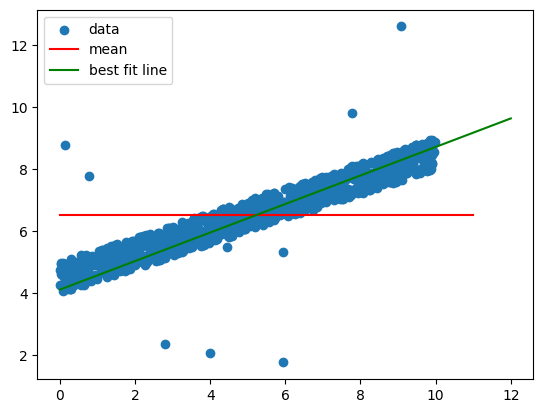

In [47]:
range=np.linspace(0,12,13)
best_fit_line=np.dot(np.c_[range,np.ones(13)],w_trained_with_outliers)
mean= np.mean(y_with_outliers)
plt.scatter(X,y_with_outliers,label="data")
plt.plot(np.array([mean]*12),color="red",label="mean")
plt.plot(range,best_fit_line,color="green",label="best fit line")
plt.legend()
plt.show()

In [53]:
print(f"R2 Score best fit line without outliers {R2_score(y_test_no_outliers,y_pred_no_outliers)}")
print(f"R2 Score best fit line with outliers {R2_score(y_test_with_outliers,y_pred_with_outliers)}")
print(f"R2 Score mean {R2_score(y_test_with_outliers,np.array([mean]*(int(test_size*simple_size))))}")



R2 Score best fit line without outliers 0.9059651603749934
R2 Score best fit line with outliers 0.8122775508824508
R2 Score mean -0.0016419740552024997


From the results, we can understand why the Mean is used as the primary baseline; it represents the **'Statistical Zero'** on this metric. It clearly illustrates the difference between training a model on **noisy** data versus **stable** data. This demonstrates whether the model is still capable of identifying underlying patterns or if it is being excessively misled by noise.

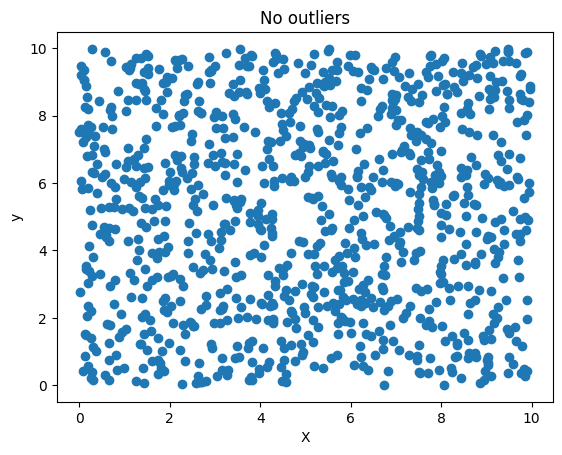

In [56]:
# testing the metrics on noise data
np.random.seed(1)
X_noise_data = np.random.random(simple_size)*10
X_noise_data_bias = np.c_[X_noise_data,np.ones(shape=(simple_size,1))]
y_noise_data = np.random.random(simple_size)*10
plot_scater(X_noise_data,y_noise_data,"noise data","x","y")


In [58]:
#train the model in this data
X_train_with_noise ,y_train_with_noise ,X_test_with_noise ,y_test_with_noise = split_data(X_noise_data_bias,y_noise_data,test_size=test_size)

w_trained_noisy=gradientDescent(X_train_with_noise,y_train_with_noise,0.001,1000)[0]
print(w_trained_noisy)
pred_noise=np.dot(X_test_with_noise,w_trained_noisy)
print(R2_score(y_test_with_noise,pred_noise))

[0.61570489 1.18976182]
-0.43109023081791564


Seeing the result as a negative value clearly shows that the model has largely failed to identify the overall pattern of the data, and this is obvious; it's pure noise.